# **05. Production Model and Insights**

In [5]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sidetable
import sklearn
import feature_engine
import scipy
from scipy import stats
from pathlib import Path
import pickle
import joblib
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder, FunctionTransformer, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge, Lasso, ElasticNet, LinearRegression
from sklearn.metrics import make_scorer, mean_squared_error, r2_score

%matplotlib inline
sns.set_style('darkgrid')


In [6]:
# Display Settings
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)


In [7]:
# define file path for processed data
parent_path = Path.cwd().parent
tuned_model_file = parent_path.joinpath("models", "final_tuned_model.pkl")
processed_data_file = parent_path.joinpath("models", "processed.pkl")
original_data_file = parent_path.joinpath("data", "raw")
files = []
for file in original_data_file.rglob("*.csv"):
    files.append(file)
    print(file.name)
    print(files.index(file), " ", file)



sample_submission.csv
0   e:\house_price_prediction\Real-Estate-Price-Prediction\data\raw\extracted\sample_submission.csv
test.csv
1   e:\house_price_prediction\Real-Estate-Price-Prediction\data\raw\extracted\test.csv
train.csv
2   e:\house_price_prediction\Real-Estate-Price-Prediction\data\raw\extracted\train.csv


In [8]:
# Load necessary data and model
print("Loading necessary data and model...")
try:
    # Load the final tuned model from previous notebook
    with open(tuned_model_file, 'rb') as f:
        tuned_model = joblib.load(f)

    # Load processed data
    with open(processed_data_file, 'rb') as f:
        processed_data = joblib.load(f)

        # Extract features and target variable
        X_train = processed_data["X_train"]
        y_train = processed_data["y_train"]
        X_test = processed_data["X_test"]
        numeric_feat = processed_data["numeric_features"]
        ordinal_feat = processed_data["ordinal_features"]
        categorical_feat = processed_data["categorical_features"]
        boolean_feat = processed_data["boolean_features"]
        year_feat = processed_data["year_features"]
        test_id = processed_data['test_id']

    # Load original data for reference and insights
    train_org = pd.read_csv(files[2])

    # standardize the column names
    train_org.columns = train_org.columns.str.strip().str.replace(" ", "_").str.replace(".", "_")
    # Drop rows where YrSold < YearRemodAdd
    train_original = train_org[train_org['YrSold'] >= train_org['YearRemodAdd']]

    print("Data and model load successfully...")
except Exception as e:
    print(f"ErrorRaised : {e}")

Loading necessary data and model...
Data and model load successfully...


## **1. Model Inspection and Documentation**

In [9]:
# Extract and document the model components
print("\n ==== MODEL DOCUMENTATION ====")

# check the model type
model_type = tuned_model.named_steps['model'].__class__.__name__
print(f"Model type : {model_type}")

# Get the hyperparameter if possible
if hasattr(tuned_model.named_steps['model'], 'alpha'):
    print(f"Alpha (regularization strength) : {tuned_model.named_steps['model'].alpha:.6f}")
if hasattr(tuned_model.named_steps['model'], 'l1_ratio'):
    print(f"L1 Ratio : {tuned_model.named_steps['model'].l1_ratio}")

# Document the preprocessing steps
print("\nPreprocessing Pipeline :")
for name, transformer, features in tuned_model.named_steps['preprocessor'].transformers_:
    if name == 'numeric':
        print(f" - Numeric Features ({len(numeric_feat)}) : {', '.join(numeric_feat[:5])}...")
        for step_name, step in transformer.steps:
            print(f"   * {step_name} : {step.__class__.__name__}")
    
    elif name == 'boolean':
        print(f"\n - Boolean Features ({len(boolean_feat)}) : {', '.join(boolean_feat[:5])}...")
        for step_name, step in transformer.steps:
            print(f"   * {step_name} : {step.__class__.__name__}")
    
    elif name == 'ordinal':
        print(f"\n - Ordinal Features ({len(ordinal_feat)}) : {', '.join(ordinal_feat[:5])}...")
        for step_name, step in transformer.steps:
            print(f"   * {step_name} : {step.__class__.__name__}")
    
    elif name == 'year':
        print(f"\n - Year Features ({len(year_feat)}) : {', '.join(year_feat[:5])}...")
        for step_name, step in transformer.steps:
            print(f"   * {step_name} : {step.__class__.__name__}")
        
    elif name == 'cat':
        print(f"\n - Categorical Features ({len(categorical_feat)}) : {", ".join(categorical_feat)}")
        for step_name, step in transformer.steps:
            print(f"   * {step_name} : {step.__class__.__name__}")

# Model performance metrics
print("\nModel Performance :")
y_pred = tuned_model.predict(X_train)
rmse = np.sqrt(mean_squared_error(y_train, y_pred))
r2 = r2_score(y_train, y_pred)
    
print(f" - RMSE on training data: ${rmse:.2f}")
print(f" - R² on training data: {r2:.4f}")


 ==== MODEL DOCUMENTATION ====
Model type : Ridge
Alpha (regularization strength) : 54.622772

Preprocessing Pipeline :
 - Numeric Features (11) : LivAreaQual, TotalSF, NeighborhoodMedianPrice, HouseAge, QualCond...
   * imputer : SimpleImputer
   * scaler : StandardScaler

 - Boolean Features (4) : HasFireplace, HasGarage, HasPorch, CentralAir...
   * bool : OrdinalEncoder

 - Ordinal Features (8) : ExterQual, KitchenQual, BsmtQual, GarageFinish, OverallQual...
   * scaler : StandardScaler

 - Year Features (1) : GarageYrBlt...
   * passthrough : str

 - Categorical Features (1) : Neighborhood
   * imputer : SimpleImputer
   * onehot : OneHotEncoder

Model Performance :
 - RMSE on training data: $30003.13
 - R² on training data: 0.8574


## **2. Feature Importance and Analysis**


=== FEATURE IMPORTANCE ANALYSIS ===

Top 20 important features :


,Features,Coefficient,Importance
0,LivAreaQual,28936.012748,28936.012748
1,NeighborhoodMedianPrice,14813.019178,14813.019178
2,Log_LivAreaQual,-9259.859006,9259.859006
3,HasGarage,8486.229782,8486.229782
4,Neighborhood_NWAmes,-8403.705153,8403.705153
5,QualCond,8300.219366,8300.219366
6,KitchenQual,-7384.536582,7384.536582
7,Log_TotalSF,7345.460947,7345.460947
8,Neighborhood_StoneBr,6357.873755,6357.873755
9,GarageCars,6063.349837,6063.349837


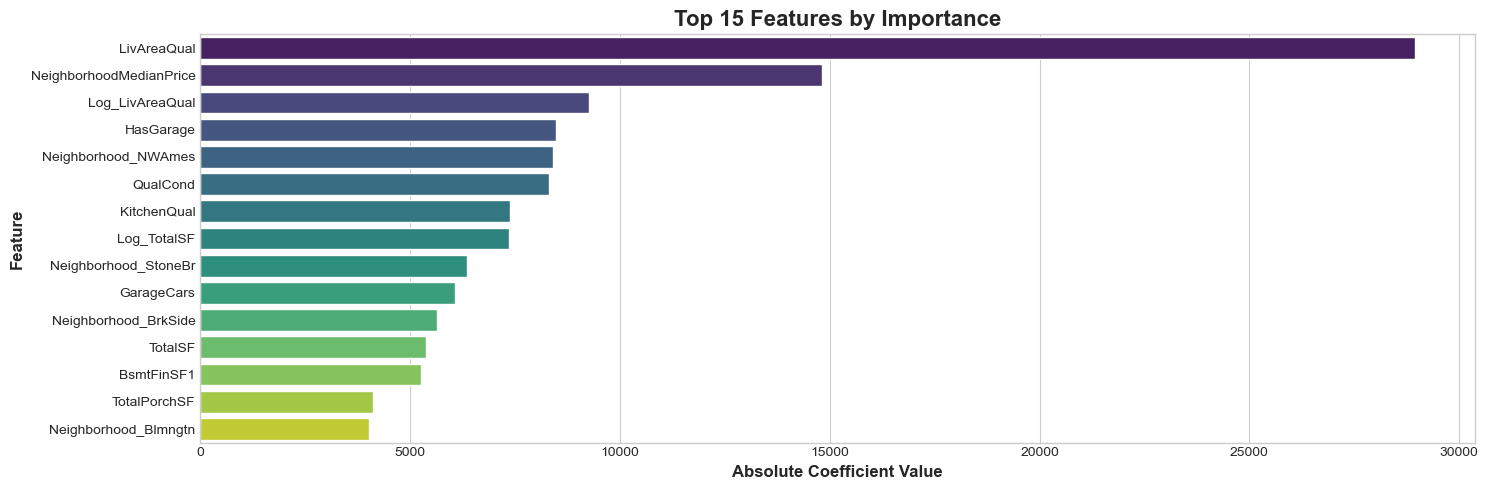

In [10]:
# Extract feature importance
print("\n=== FEATURE IMPORTANCE ANALYSIS ===")
def get_feature_importance(model, numeric_feat, ordinal_feat, boolean_feat, year_feat, categorical_feat):
    """Extract feature importance from linear models with safety for missing categorical features"""
    try:
        # Get features names after preprocessing 
        all_features = numeric_feat + ordinal_feat + boolean_feat + year_feat

        # Check if there is categorical features and if they're in preprocessor
        if len(categorical_feat) > 0 and 'cat' in model.named_steps['preprocessor'].named_transformers_:
            cat_encode = model.named_steps['preprocessor'].named_transformers_['cat']
            if hasattr(cat_encode, 'get_feature_names_out'):
                encoded_cat_features = cat_encode.get_feature_names_out(categorical_feat)
            else:
                encoded_cat_features = cat_encode.named_steps['onehot'].get_feature_names_out(categorical_feat)
            all_features.extend(encoded_cat_features)

        # Get coefficient from the model
        coef = model.named_steps['model'].coef_

        # Create dataframe
        importance_df = pd.DataFrame({
            'Features' : all_features,
            'Coefficient' : coef,
            'Importance' : np.abs(coef)
        })
        return importance_df.sort_values(by='Importance', ascending=False, ignore_index=True)
 
    except Exception as e:
        all_features = numeric_feat + ordinal_feat + boolean_feat + year_feat 
        print(f"Error Raised extracting feature importance : {e}")
        return pd.DataFrame({'Features' : all_features, 'Importance': np.nan})

# Get and display feature importance
feature_importance = get_feature_importance(tuned_model, numeric_feat, ordinal_feat, boolean_feat, year_feat, categorical_feat)

# Display top 20 features
print("\nTop 20 important features :")
display(feature_importance.head(20))

# Visualize feature importance
fig, ax = plt.subplots(figsize=(15, 5))
sns.barplot(x='Importance', y='Features', data=feature_importance.head(15), palette='viridis', ax=ax)
ax.set_title('Top 15 Features by Importance', fontsize=16, fontweight='bold')
ax.set_xlabel('Absolute Coefficient Value', fontsize=12, fontweight='bold')
ax.set_ylabel('Feature', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

In [11]:
feature_importance['Features'].str.split("").str[0].unique()

array([''], dtype=object)


Importance by feature category:


Category
Location     $78,036.9688
Size         $56,181.3203
Amenities    $32,463.5165
Quality      $21,593.5631
Age           $4,076.5664
Rooms         $2,351.9332
Name: Importance, dtype: object

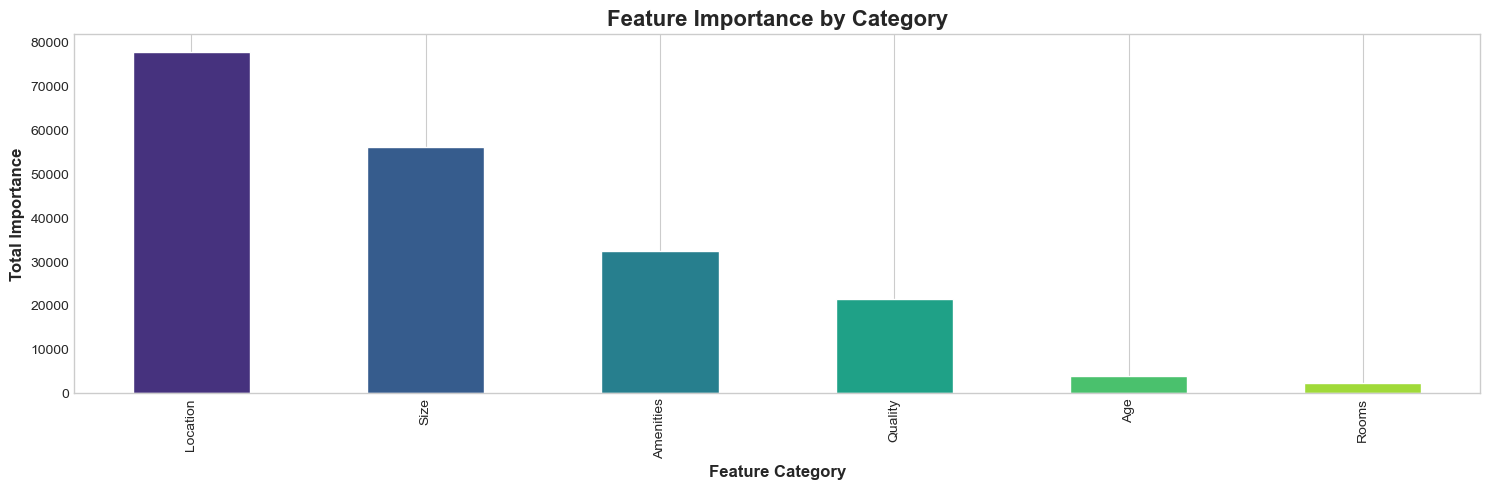

In [12]:
# Sort feature importance into categories. 
# Define these categories with the dataset's actual column names
feature_categories = {
    'Location' : ['Neighborhood', 'NeighborhoodMedianPrice'],
    'Amenities' : ['HasFireplace', 'Fireplaces', 'HasGarage', 'GarageCars', 'GarageFinish', 'CentralAir', 'HasPorch', 'TotalPorchSF', 'MasVnrArea'],
    'Age' : ['HouseAge', 'RemodeledAge', 'GarageYrBlt'],
    'Size' : ['TotalSF', 'Log_TotalSF', 'BsmtFinSF1', 'LivAreaQual', 'Log_LivAreaQual'],
    'Quality' : ['KitchenQual', 'QualCond', 'ExterQual', 'OverallQual', 'BsmtQual'],
    'Rooms' : ['TotalBath']
}

def categorize_feature(feature_name):
    for category, keyword in feature_categories.items():
        if any(k in feature_name for k in keyword):
            return category
    return 'Other'

# Add category to importance DataFrame
feature_importance['Category'] = feature_importance['Features'].apply(categorize_feature)

# Group by category and sum importance
category_importance = feature_importance.groupby('Category')['Importance'].sum().sort_values(ascending=False)
print("\nImportance by feature category:")
display(category_importance.apply(lambda x: f"${x:,.4f}"))

# Visualize importance by category
plt.figure(figsize=(15, 5))
category_importance.plot(kind='bar', color=sns.color_palette('viridis', n_colors=len(category_importance.index)))
plt.title('Feature Importance by Category', fontsize=16, fontweight='bold')
plt.xlabel('Feature Category', fontsize=12, fontweight='bold')
plt.ylabel('Total Importance', fontsize=12, fontweight='bold')
plt.grid(axis='y')

plt.tight_layout()
plt.show()

## **3. Primary Drivers Analysis**


 ==== PRIMARY DRIVERS ANALYSIS ====
Price impact of improvements:
 - Increasing Overall Quality by 1 point: $3895.61
 - Increasing Total Square Feet by 10%: $699.65
 - Adding one full bathroom: $2351.93
 - Adding one garage space: $6063.35
 - Adding a fireplace: $1012.71


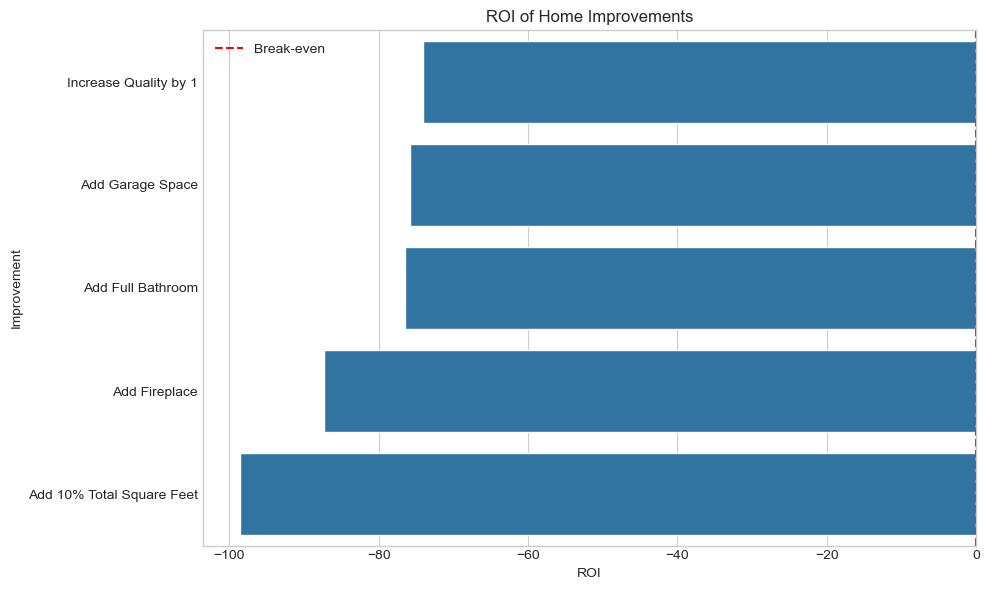

In [13]:
# Analyze the primary drivers for real estate investors
print("\n ==== PRIMARY DRIVERS ANALYSIS ====")

# user defined function to compute price impact
def compute_price_impact(feature, change_amount, mean_value=None):
    """Estimate price impact from a feature change"""
    # Find the coefficient for this feature
    if feature in feature_importance['Features'].values:
        coef = feature_importance.loc[feature_importance['Features'] == feature, 'Coefficient'].values[0]
    else:
        print(f"Feature {feature} not found in model")
        return None
    
    # if there is a log-transformed feature, we need to adjust the calculation
    if 'Log_' in feature:
        if mean_value is None:
            print(f"Mean value required for {feature}")
            return None
        # For log features, compute the effect of a percentage increase
        current_log = np.log1p(mean_value)
        new_log = np.log1p(mean_value * (1 + change_amount/100))
        log_change = new_log - current_log
        impact = coef * log_change
    else:
        # For regular features, just multiply the coefficient by the change
        impact = coef * change_amount

    return impact
        
# Calculate price impact on primary features (using your exact column names)
print("Price impact of improvements:")

# For quality improvements - ensure the feature exists in the model before calculating
if 'OverallQual' in feature_importance['Features'].values:
    quality_impact = compute_price_impact('OverallQual', 1)
    print(f" - Increasing Overall Quality by 1 point: ${quality_impact:.2f}")

# For size improvements (assuming mean living area of 1500 sq ft)
if 'Log_TotalSF' in feature_importance['Features'].values:
    size_impact = compute_price_impact('Log_TotalSF', 10, 1500)  # 10% increase
    print(f" - Increasing Total Square Feet by 10%: ${size_impact:.2f}")

# For bathroom additions
if 'TotalBath' in feature_importance['Features'].values:
    bath_impact = compute_price_impact('TotalBath', 1)
    print(f" - Adding one full bathroom: ${bath_impact:.2f}")

# For garage additions
if 'GarageCars' in feature_importance['Features'].values:
    garage_impact = compute_price_impact('GarageCars', 1)
    print(f" - Adding one garage space: ${garage_impact:.2f}")

# For fireplaces
if 'HasFireplace' in feature_importance['Features'].values:
    fireplace_impact = compute_price_impact('HasFireplace', 1)
    print(f" - Adding a fireplace: ${fireplace_impact:.2f}")

# Create a DataFrame for visualization - only include features that exist in the model
improvements = []

options = {
    'OverallQual': ("Increase Quality by 1", quality_impact, 15000),
    'Log_TotalSF': ("Add 10% Total Square Feet", size_impact, 50000),
    'TotalBath': ("Add Full Bathroom", bath_impact, 10000),
    'GarageCars': ("Add Garage Space", garage_impact, 25000),
    'HasFireplace': ("Add Fireplace", fireplace_impact, 8000)
}

# Create DataFrame from valid improvements
for feat, (name, impact, cost) in options.items():
    if feat in feature_importance['Features'].values:
        improvements.append({
            'Improvement': name,
            'Price Impact': impact,
            'Cost': cost,
            'ROI': ((impact / cost) - 1) * 100
        })

if improvements:
    df = pd.DataFrame(improvements).sort_values('ROI', ascending=False)
    plt.figure(figsize=(10, 6))
    sns.barplot(x='ROI', y='Improvement', data=df)
    plt.title('ROI of Home Improvements')
    plt.axvline(x=0, color='red', linestyle='--', label='Break-even')
    plt.legend()
    plt.tight_layout()
    plt.show()



## **4. Neighborhood Analysis**


=== NEIGHBORHOOD ANALYSIS ===

Top neighborhoods by median price:


,Neighborhood,mean_price,median_price,price_stddev,sales_count
0,NridgHt,316270.623377,315000.0,96392.544954,77
1,NoRidge,335295.317073,301500.0,121412.658640,41
2,StoneBr,310499.000000,278000.0,112969.676640,25
3,Timber,242247.447368,228475.0,64845.651549,38
4,Somerst,225379.837209,225500.0,56177.555888,86
5,Veenker,238772.727273,218000.0,72369.317959,11
6,Crawfor,210624.725490,200624.0,68866.395472,51
7,ClearCr,212565.428571,200250.0,50231.538993,28
8,CollgCr,197965.773333,197200.0,51403.666438,150
9,Blmngtn,194870.882353,191000.0,30393.229219,17



Neighborhoods with most sales:


,Neighborhood,mean_price,median_price,price_stddev,sales_count
0,NAmes,145847.080000,140000.0,33075.345450,225
1,CollgCr,197965.773333,197200.0,51403.666438,150
2,OldTown,128225.300885,119000.0,52650.583185,113
3,Edwards,127648.686869,120000.0,43047.614209,99
4,Somerst,225379.837209,225500.0,56177.555888,86
5,Gilbert,192854.506329,181000.0,35986.779085,79
6,NridgHt,316270.623377,315000.0,96392.544954,77
7,Sawyer,136793.135135,135000.0,22345.129157,74
8,NWAmes,189050.068493,182900.0,37172.218106,73
9,SawyerW,186555.796610,179900.0,55651.997820,59



Neighborhood by price per square foot :


C:\Users\Admin\AppData\Local\Temp\ipykernel_9000\614403375.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_original.loc[:, 'PricePerSF'] = train_original['SalePrice'] / train_original['GrLivArea']


Neighborhood
NridgHt    157.957245
StoneBr    157.864524
Veenker    143.819334
Somerst    137.352058
Blmngtn    137.122417
CollgCr    134.515817
Timber     133.998170
Mitchel    132.912458
NoRidge    128.190843
Sawyer     120.766654
Name: PricePerSF, dtype: float64

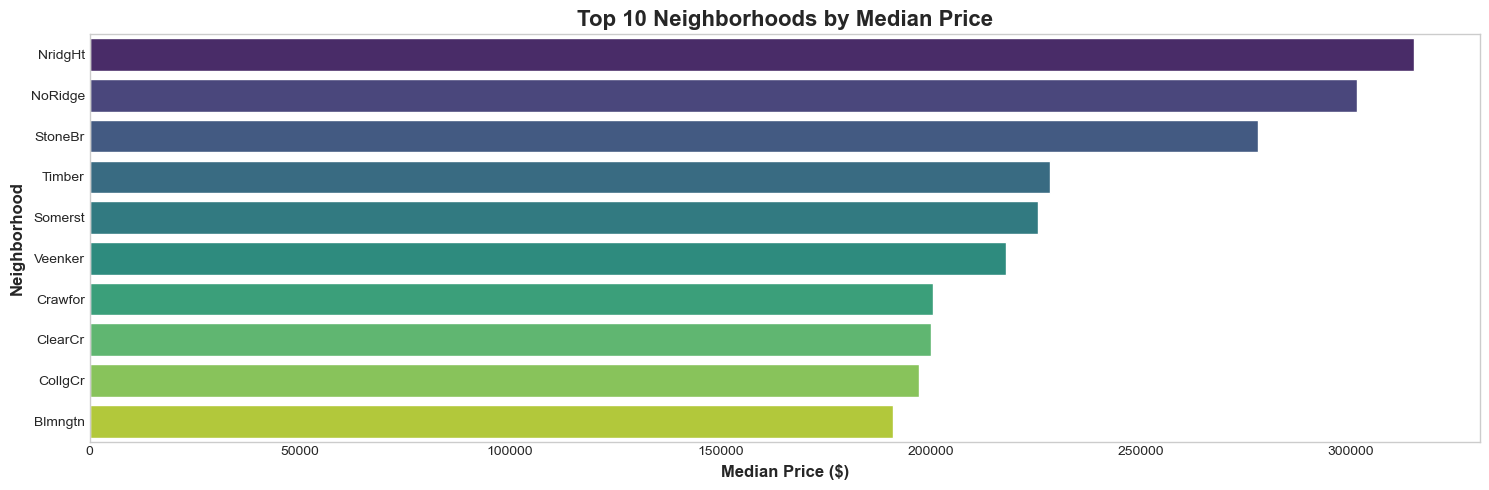

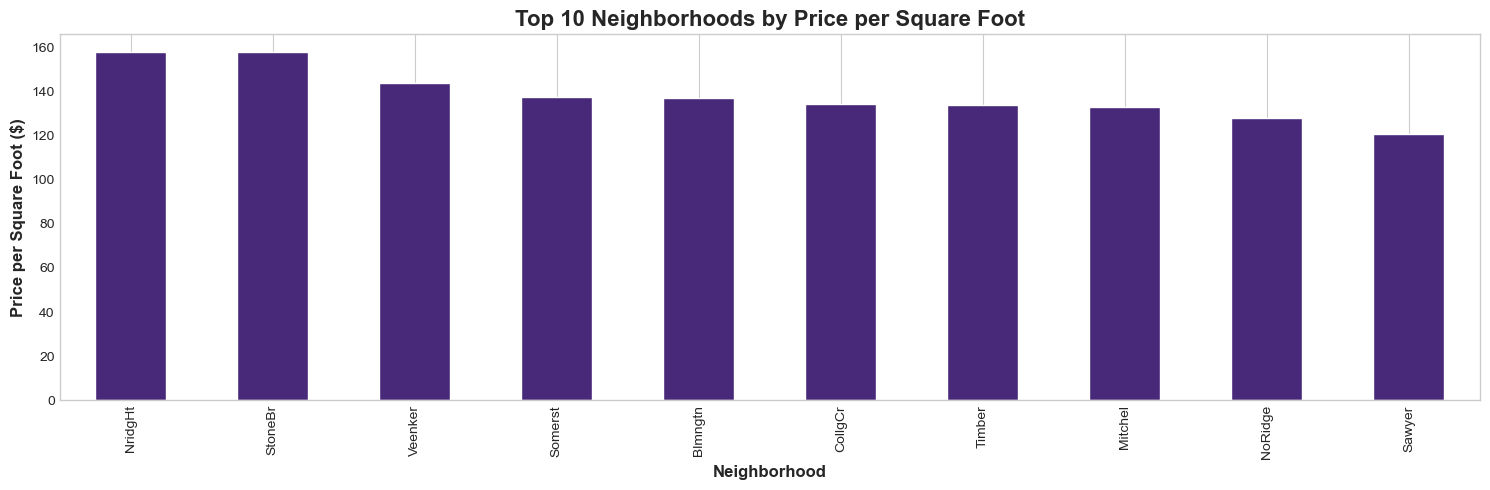


Best value neighborhoods (lowest price per quality point):


,Neighborhood,OverallQual,median_price,PricePerQualPoints
0,BrDale,5.687500,106000.0,18637.362637
1,MeadowV,4.470588,88000.0,19684.210526
2,IDOTRR,4.756757,103000.0,21653.409091
3,OldTown,5.389381,119000.0,22080.459770
4,Blueste,6.000000,137500.0,22916.666667
5,Edwards,5.030303,120000.0,23855.421687
6,NPkVill,6.000000,146000.0,24333.333333
7,BrkSide,5.051724,124300.0,24605.460751
8,SWISU,5.440000,139500.0,25643.382353
9,NAmes,5.360000,140000.0,26119.402985


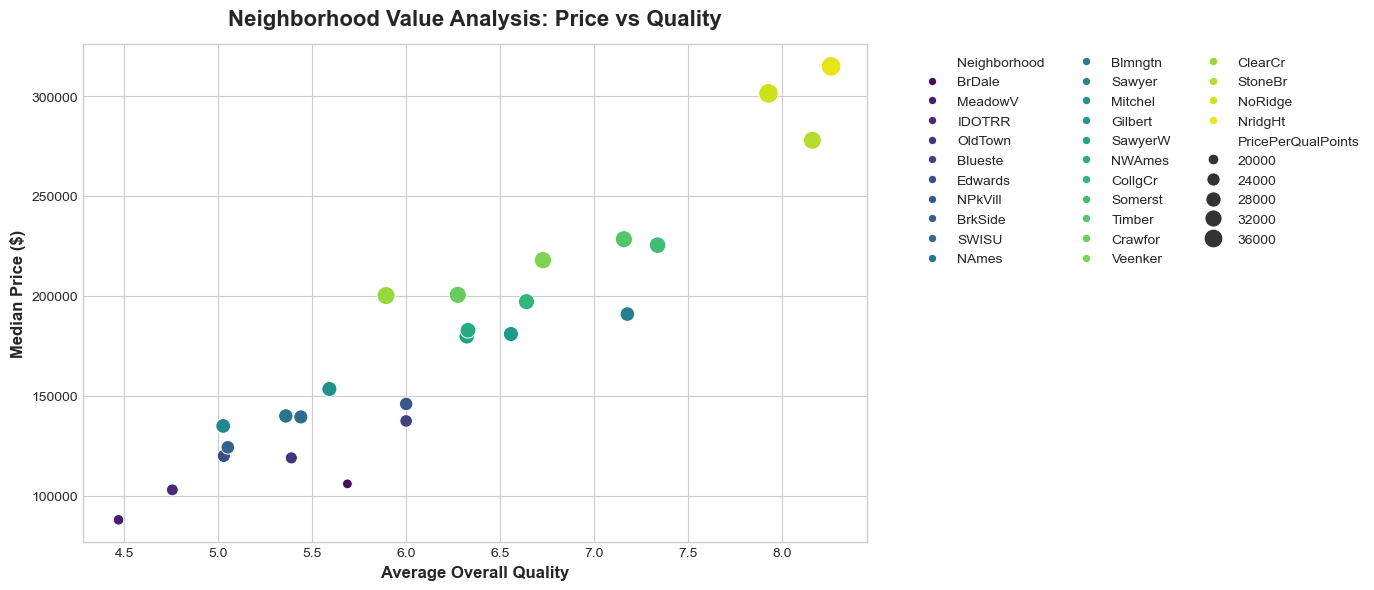

In [14]:
print("\n=== NEIGHBORHOOD ANALYSIS ===")
colors = sns.color_palette('viridis', 8)
# Extract neighborhood price information from original data - adapt to your column names
train_price_col = 'SalePrice' if 'SalePrice' in train_original.columns else 'Sale_Price'
train_neighborhood_col = 'Neighborhood' if 'Neighborhood' in train_original.columns else 'neighborhood'
train_grlivarea_col = 'GrLivArea' if 'GrLivArea' in train_original.columns else 'gr_liv_area'

# Group by neighborhood to get statistics
nbdh_stats = train_original.groupby(train_neighborhood_col).agg({
    train_price_col: ['mean', 'median', 'std', 'count']
}).reset_index()

# Flatten the column names
nbdh_stats.columns = [train_neighborhood_col, 'mean_price', 'median_price', 'price_stddev', 'sales_count']

# Sort by median price
nbdh_stats = nbdh_stats.sort_values('median_price', ascending=False, ignore_index=True)

# Display top neighborhoods by price
print("\nTop neighborhoods by median price:")
display(nbdh_stats.head(10))

# Display neighborhoods with most sales
print("\nNeighborhoods with most sales:")
display(nbdh_stats.sort_values('sales_count', ascending=False, ignore_index=True).head(10))

# Calculate price per square foot by neighborhood - with error handling for missing columns
try:
    train_original.loc[:, 'PricePerSF'] = train_original['SalePrice'] / train_original['GrLivArea']
    nbdh_price_stats = train_original.groupby(['Neighborhood'])['PricePerSF'].median().sort_values(ascending=False)
    print("\nNeighborhood by price per square foot :")
    display(nbdh_price_stats.head(10))

except Exception as e:
    print(f"\nCouldn't compute price per square feet : {e}")
    nbdh_price_stats = pd.Series()

# Visualize top 10 neighborhood median prices
fig, ax = plt.subplots(figsize=(15, 5))
sns.barplot(x='median_price', y=train_neighborhood_col,
            data=nbdh_stats.head(10), palette='viridis', ax=ax)
ax.set_title('Top 10 Neighborhoods by Median Price', fontsize=16, fontweight='bold')
ax.set_xlabel('Median Price ($)', fontsize=12, fontweight='bold')
ax.set_ylabel('Neighborhood', fontsize=12, fontweight='bold')

plt.grid(axis='x')
plt.tight_layout()
plt.show()

# Visualize price per square foot by neighborhood if it was calculated
if not nbdh_price_stats.empty:
    plt.figure(figsize=(15, 5))
    nbdh_price_stats.head(10).plot(kind='bar', color=colors[0])
    plt.title('Top 10 Neighborhoods by Price per Square Foot', fontsize=16, fontweight='bold')
    plt.xlabel('Neighborhood', fontsize=12, fontweight='bold')
    plt.ylabel('Price per Square Foot ($)', fontsize=12, fontweight='bold')
    
    plt.grid(axis='y')
    plt.tight_layout()
    plt.show()

# Analyze ROI potential by neighborhood
# Compare price to overall quality by neighborhood
overall_qual_col = 'OverallQual' if 'OverallQual' in train_original.columns else 'overall_qual'
try:
    nbdh_qual = train_original.groupby(train_neighborhood_col)[overall_qual_col].mean().reset_index()
    nbdh_qual = nbdh_qual.merge(nbdh_stats[[train_neighborhood_col, 'median_price']])
    nbdh_qual.loc[:, 'PricePerQualPoints'] = nbdh_qual['median_price'] / nbdh_qual[overall_qual_col]
    nbdh_qual = nbdh_qual.sort_values('PricePerQualPoints', ignore_index=True)
    print("\nBest value neighborhoods (lowest price per quality point):")
    display(nbdh_qual.head(10))

    # Visualize value neighborhoods
    plt.figure(figsize=(14, 6))
    sns.scatterplot(x=overall_qual_col, y='median_price',
                    data=nbdh_qual,
                    hue=train_neighborhood_col,
                    size='PricePerQualPoints',
                    sizes=(50, 200),
                    palette='viridis')
    plt.title('Neighborhood Value Analysis: Price vs Quality', fontsize=16, fontweight='bold', y=1.02)
    plt.xlabel('Average Overall Quality', fontsize=12, fontweight='bold')
    plt.ylabel('Median Price ($)', fontsize=12, fontweight='bold')
    plt.legend(bbox_to_anchor=(1.05, 1), ncols=3, loc='upper left')
    
    plt.grid(True)
    plt.tight_layout()
    plt.show()


except Exception as e:
    print(f"\nError in neighborhood ROI analysis: {e}")

## **5. Investment Strategy Insights**


==== INVESTMENT STRATEGY INSIGHTS ====

Price by home age:


,mean,median,count
AgeGroup,,,
0-10 years,234566.762162,214000.0,370
11-20 years,234832.600000,209450.0,130
21-40 years,158938.117216,149900.0,273
41-60 years,144104.232628,139000.0,331
61-100 years,130817.238636,120250.0,264
100+ years,153118.035714,123250.0,28



Renovation premium by age group:


,NoRecentRenovation,RecentRenovation,RenovationPremium,PremiumPercentage
AgeGroup,,,,
0-10 years,213750.0,215100.0,1350.0,0.631579
11-20 years,208900.0,290000.0,81100.0,38.822403
21-40 years,149700.0,150500.0,800.0,0.534402
41-60 years,139000.0,145250.0,6250.0,4.496403
61-100 years,120500.0,119000.0,-1500.0,-1.244813
100+ years,122500.0,145900.0,23400.0,19.102041


<Figure size 1500x500 with 0 Axes>

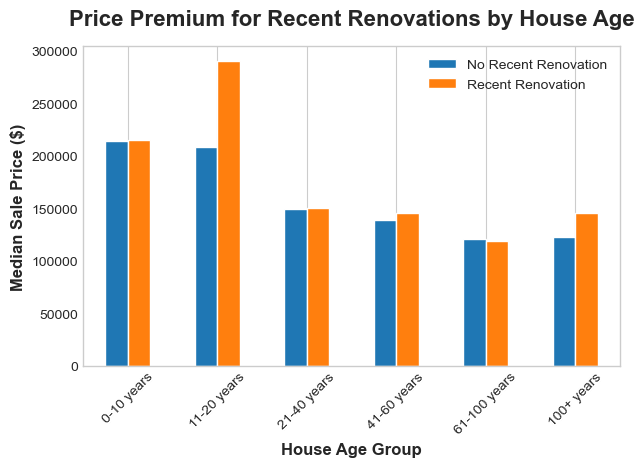

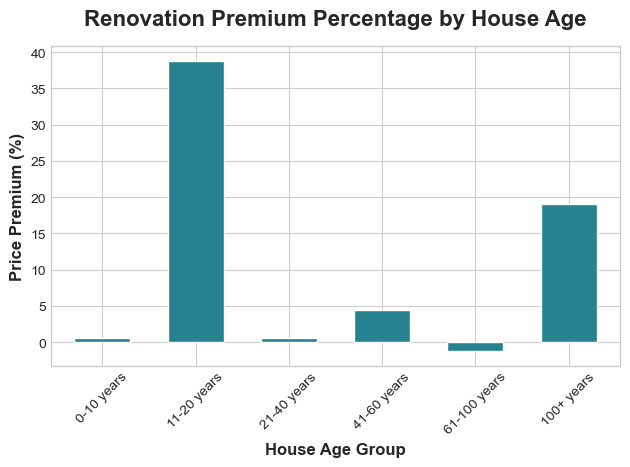


Quality premium by building type:


BldgType,1Fam,2fmCon,Duplex,Twnhs,TwnhsE,1Fam_premium,2fmCon_premium,Duplex_premium,Twnhs_premium,TwnhsE_premium
OverallQual,,,,,,,,,,
1,50150.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,60000.0,NaN,NaN,NaN,NaN,9850.0,NaN,NaN,NaN,NaN
3,81500.0,95000.0,92900.0,NaN,NaN,21500.0,NaN,NaN,NaN,NaN
4,109950.0,109625.0,105379.5,85250.0,81750.0,28450.0,14625.0,12479.5,NaN,NaN
5,133000.0,131500.0,137000.0,112000.0,125000.0,23050.0,21875.0,31620.5,26750.0,43250.0
6,165600.0,138500.0,137000.0,118000.0,147500.0,32600.0,7000.0,0.0,6000.0,22500.0
7,205000.0,122000.0,188650.0,162500.0,182450.0,39400.0,-16500.0,51650.0,44500.0,34950.0
8,275000.0,NaN,NaN,174000.0,236500.0,70000.0,NaN,NaN,11500.0,54050.0
9,360000.0,NaN,NaN,NaN,318980.5,85000.0,NaN,NaN,NaN,82480.5


<Figure size 1500x1000 with 0 Axes>

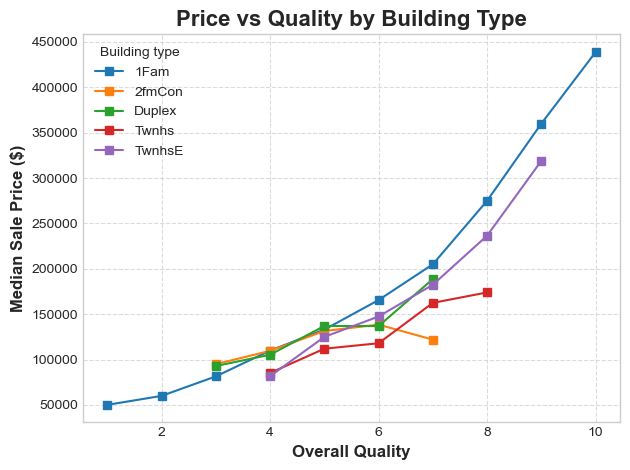

In [20]:
print("\n==== INVESTMENT STRATEGY INSIGHTS ====")

# extract column names from original dataset for analysis
yr_sold_col = 'YrSold' if 'YrSold' in train_original.columns else 'Yr_Sold'
year_built_col = 'YearBuilt' if 'YearBuilt' in train_original.columns else 'Year_Built'
year_remod_col = 'YearRemodAdd' if 'YearRemodAdd' in train_original.columns else 'Year_Remod/Add'
bldg_type_col = 'BldgType' if 'BldgType' in train_original.columns else 'Bldg_Type'

# Analyze the price and age to find renovation opportunity --- with safety checks
try:
    train_original = train_original.assign(HouseAge=train_original[yr_sold_col] - train_original[year_built_col])
    train_original = train_original.assign(RecentRenovation=(train_original[yr_sold_col] - train_original[year_remod_col] <= 5).astype(int))

    # Group by age ranges
    age_bins = [0, 10, 20, 40, 60, 100, 200]
    age_labels = ['0-10 years', '11-20 years', '21-40 years', '41-60 years', '61-100 years', '100+ years']
    train_original = train_original.assign(AgeGroup=pd.cut(train_original['HouseAge'], bins=age_bins, labels=age_labels))

    # Price by age group
    age_price = train_original.groupby('AgeGroup')[train_price_col].agg(['mean', 'median', 'count'])
    print("\nPrice by home age:")
    display(age_price)

    # Renovation premium analysis
    reno_premium = train_original.groupby(['AgeGroup', 'RecentRenovation'])[train_price_col].median().reset_index()
    reno_premium = reno_premium.pivot(index='AgeGroup', columns='RecentRenovation', values=train_price_col)
    reno_premium.columns = ['NoRecentRenovation', 'RecentRenovation']
    reno_premium['RenovationPremium'] = reno_premium['RecentRenovation'] - reno_premium['NoRecentRenovation']
    reno_premium['PremiumPercentage'] = (reno_premium['RenovationPremium'] / reno_premium['NoRecentRenovation']) * 100
    print("\nRenovation premium by age group:")
    display(reno_premium)

    # visualize through bar to compare median price of recent vs not recent renovation
    plt.figure(figsize=(15, 5))
    reno_premium[reno_premium.columns[:2].tolist()].plot(kind='bar')
    plt.ylabel('Median Sale Price ($)', fontsize=12, fontweight='bold')
    plt.xlabel("House Age Group", fontsize=12, fontweight='bold')
    plt.title('Price Premium for Recent Renovations by House Age', fontsize=16, fontweight='bold', y=1.04)
    plt.tick_params(axis='x', rotation=45)
    new_labels = ['No Recent Renovation', 'Recent Renovation']
    plt.legend(labels=new_labels)
    plt.grid(axis='y')
    plt.tight_layout()
    plt.show()

    # Visualize renovation premium percentage
    #plt.figure(figsize=(6, 4))
    reno_premium['PremiumPercentage'].plot(kind='bar', width=0.6, color=colors[3])
    plt.title('Renovation Premium Percentage by House Age', fontsize=16, fontweight='bold', y=1.04)
    plt.xlabel('House Age Group', fontsize=12,fontweight='bold')
    plt.ylabel('Price Premium (%)', fontsize=12, fontweight='bold')
    plt.tick_params(axis='x', rotation=45)
    plt.grid('both')
    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"Error raised in age/remodel analysis : {e}")

# Comparing ROI by property type with respect to overall quality
try:
    if bldg_type_col in train_original.columns and overall_qual_col in train_original.columns:
        house_type_quality = train_original.groupby([bldg_type_col, overall_qual_col])[train_price_col].median().reset_index()
        house_type_quality = house_type_quality.pivot(index=overall_qual_col, columns=bldg_type_col, values=train_price_col)

        # compute quality premium for each house type
        for col in house_type_quality.columns:
            house_type_quality[f"{col}_premium"] = house_type_quality[col].diff()

        print("\nQuality premium by building type:")
        display(house_type_quality)

        # visualize the quality with median saleprice across building type
        plt.figure(figsize=(15, 10))
        house_type_quality[house_type_quality.columns[:5].tolist()].plot(kind='line', marker='s')
        plt.title('Price vs Quality by Building Type', fontsize=16, fontweight='bold')
        plt.xlabel('Overall Quality', fontsize=12, fontweight='bold', y=1.04)
        plt.ylabel('Median Sale Price ($)', fontsize=12, fontweight='bold')
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.legend(title='Building type', fancybox=True)
        plt.tight_layout()
        plt.show()

except Exception as e:
    print(f"Error in building type analysis: {e}")

## **6. Prediction Function for Investors**

In [18]:
# Create a user-friendly prediction functions for investors
print("\n===== CREATING INVESTMENT PREDICTION TOOL =====")
def create_prediction_function(model, numeric_features, categorical_features, ordinal_features, boolean_features, year_features):
    """Simplified prediction function for investors"""

    # Combine all features into one list
    all_features = numeric_features + categorical_features + ordinal_features + boolean_features + year_features

    def predict_price(feature_dict):
        # fill missing values with defaults
        input_data = {}
        for f in all_features:
            if f in categorical_features:
                input_data[f] = feature_dict.get(f, None) # default None
            else:
                input_data[f] = feature_dict.get(f, 0) # default 0

        # convert to dataframe
        input_df = pd.DataFrame([input_data])

        # Predict
        try:
            return model.predict(input_df[all_features])[0]
        except Exception as e:
            return f"Prediction error : {e}"
        
    return predict_price


# Create the prediction function
price_predictor = create_prediction_function(tuned_model, numeric_feat, categorical_feat, ordinal_feat, boolean_feat, year_feat)
all_features = numeric_feat + categorical_feat + ordinal_feat + year_feat + boolean_feat
# Example
example_house = {
    'LivAreaQual': 1800 * 7, # LivArea x Qual
    'TotalSF': 2400, # total square ft
    'Log_TotalSF': np.log1p(2400),
    'NeighborhoodMedianPrice': 250000, # example value
    'HouseAge': 56, # as of 2026
    'QualCond': 35, # Qual x Condition (7 x 5)
    'RemodeledAge': 10, # Year since remodeled
    'MasVnrArea': 200,
    'TotalPorchSF': 100, # total porch area
    'BsmtFinSF1': 1000, # finished basement area
    'Log_LivAreaQual': np.log1p(1800 * 7),
    'ExterQual': 4, # good quality
    'KitchenQual': 4, # good quality
    'BsmtQual': 4, # good quality
    'GarageFinish': 1,
    'OverallQual': 7,
    'GarageCars': 2, 
    'Fireplaces': 0, # no. of fireplace
    'TotalBath': 2.5,
    'HasFireplace': 0, # has a fireplace
    'HasGarage': 1, # has a garage
    'HasPorch': 1, # has a porch
    'CentralAir': 1, # has a central air
    'GarageYrBlt': 1970,
    'Neighborhood': 'NridgHt', # example Neighborhood
    }
# only inclued features that are actually in model
example_house_filtered = {k : v for k, v in example_house.items() if k in all_features}

# prediction
predicted_price = price_predictor(example_house_filtered)
print(f"Predicted price for example house : ${predicted_price:,.2f}")

# Create a simple function documentation for investors
print("\n=== INVESTOR PREDICTION FUNCTION DOCUMENTATION ===")
print("""
To use the house price prediction tool:
1. Create a dictionary with the following keys (only include features that are in the model):
    - LivAreaQual: Living area multiplied by overall quality (e.g., 1800 sqft x 7 quality = 12600)
    - TotalSF: Total square footage of the house (e.g., 2400)
    - Log_TotalSF: Log-transformed total square footage (e.g., log1p(2400))
    - NeighborhoodMedianPrice: Median price of the neighborhood (e.g., 250000)
    - HouseAge: Age of the house in years (e.g., 56)
    - QualCond: Overall quality multiplied by overall condition (e.g., 7 x 5 = 35)
    - RemodeledAge: Years since last remodel (e.g., 10) 
    - MasVnrArea: Masonry veneer area in square feet (e.g., 200)
    - TotalPorchSF: Total porch area in square feet (e.g., 100)
    - BsmtFinSF1: Finished basement area in square feet (e.g., 1000)
    - Log_LivAreaQual: Log-transformed living area multiplied by overall quality (e.g., log1p(1800 x 7))
    - ExterQual: Exterior quality rating (1-5, where 5 is best) (e.g., 4)
    - KitchenQual: Kitchen quality rating (1-5, where 5 is best) (e.g., 4)
    - BsmtQual: Basement quality rating (1-5, where 5 is best) (e.g., 4)
    - GarageFinish: Garage finish rating (0-3, where 3 is best) (e.g., 1)
    - OverallQual: Overall quality rating (1-10, where 10 is best) (e.g., 7)
    - GarageCars: Number of garage spaces (e.g., 2)
    - Fireplaces: Number of fireplaces (e.g., 0)
    - TotalBath: Total number of bathrooms (e.g., 2.5)
    - HasFireplace: 1 if the house has a fireplace, 0 otherwise (e.g., 0)
    - HasGarage: 1 if the house has a garage, 0 otherwise (e.g., 1)
    - HasPorch: 1 if the house has a porch, 0 otherwise (e.g., 1)
    - CentralAir: 1 if the house has central air conditioning, 0 otherwise (e.g., 1)
    - GarageYrBlt: Year the garage was built (e.g., 1970)
    - Neighborhood: Name of the neighborhood (e.g., 'NridgHt', 'CollgCr', etc.)
      
NOTE: Only include the features that are actually used in the model. If a feature is not included, it will be ignored in the prediction.

2. Pass this dictionary to the prediction function.
3. The function will return the predicted sale price in dollars for the house based on the input features.
""")


===== CREATING INVESTMENT PREDICTION TOOL =====
Predicted price for example house : $225,644.73

=== INVESTOR PREDICTION FUNCTION DOCUMENTATION ===

To use the house price prediction tool:
1. Create a dictionary with the following keys (only include features that are in the model):
    - LivAreaQual: Living area multiplied by overall quality (e.g., 1800 sqft x 7 quality = 12600)
    - TotalSF: Total square footage of the house (e.g., 2400)
    - Log_TotalSF: Log-transformed total square footage (e.g., log1p(2400))
    - NeighborhoodMedianPrice: Median price of the neighborhood (e.g., 250000)
    - HouseAge: Age of the house in years (e.g., 56)
    - QualCond: Overall quality multiplied by overall condition (e.g., 7 x 5 = 35)
    - RemodeledAge: Years since last remodel (e.g., 10) 
    - MasVnrArea: Masonry veneer area in square feet (e.g., 200)
    - TotalPorchSF: Total porch area in square feet (e.g., 100)
    - BsmtFinSF1: Finished basement area in square feet (e.g., 1000)
    - Log

In [19]:
# save the model and prediction function
# step1 : Create a directory/folder for models if it doesn't exist
model_dir = parent_path.joinpath("models")
model_dir.mkdir(parents=True, exist_ok=True)

# Step 2: # Define file path inside model directory
prediction_file_path = model_dir.joinpath("production_model.joblib")

# Save the production model as a joblib file
with open(prediction_file_path, 'wb') as f:
    joblib.dump(tuned_model, f)

print("Production model saved successfully!!!!!")
# Load it back to verify
with open(prediction_file_path, 'rb') as f:
    model = joblib.load(f)


Production model saved successfully!!!!!
